In [1]:
#Setup Gdrive file download extention 
!conda install -y gdown

Retrieving notices: ...working... done
Channels:
 - rapidsai
 - nvidia
 - conda-forge
 - defaults
 - pytorch
Platform: linux-64
Solving environment: done

## Package Plan ##

  environment location: /opt/conda

  added / updated specs:
    - gdown


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2024.7.4   |       hbcca054_0         151 KB  conda-forge
    certifi-2024.7.4           |     pyhd8ed1ab_0         156 KB  conda-forge
    conda-24.7.1               |  py310hff52083_0         940 KB  conda-forge
    filelock-3.15.4            |     pyhd8ed1ab_0          17 KB  conda-forge
    gdown-5.2.0                |     pyhd8ed1ab_0          21 KB  conda-forge
    openssl-3.3.1              |       h4bc722e_2         2.8 MB  conda-forge
    ------------------------------------------------------------
                                           Total:         4.0 MB

The fol

In [2]:
# !gdown --id <File ID>
!gdown --id 1SdJEoAna8Z4bJ3_dJ23D4ldYlaxyWRor

/opt/conda/lib/python3.10/site-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1SdJEoAna8Z4bJ3_dJ23D4ldYlaxyWRor
From (redirected): https://drive.google.com/uc?id=1SdJEoAna8Z4bJ3_dJ23D4ldYlaxyWRor&confirm=t&uuid=ab57328d-755d-4263-9727-3f0632c475cd
To: /kaggle/working/all Photos.zip
100%|██████████████████████████████████████| 1.81G/1.81G [00:24<00:00, 73.8MB/s]


In [3]:
!unzip 'all Photos.zip'

Archive:  all Photos.zip
  inflating: all Photos/1.jpg        
  inflating: all Photos/10.jpg       
  inflating: all Photos/100.jpg      
  inflating: all Photos/1000.jpg     
  inflating: all Photos/1001.jpg     
  inflating: all Photos/1002.jpg     
  inflating: all Photos/1003.jpg     
  inflating: all Photos/1004.jpg     
  inflating: all Photos/1005.jpg     
  inflating: all Photos/1006.jpg     
  inflating: all Photos/1007.jpg     
  inflating: all Photos/1008.jpg     
  inflating: all Photos/1009.jpg     
  inflating: all Photos/101.jpg      
  inflating: all Photos/1010.jpg     
  inflating: all Photos/1011.jpg     
  inflating: all Photos/1012.jpg     
  inflating: all Photos/1013.jpg     
  inflating: all Photos/1014.jpg     
  inflating: all Photos/1015.jpg     
  inflating: all Photos/1016.jpg     
  inflating: all Photos/1017.jpg     
  inflating: all Photos/1018.jpg     
  inflating: all Photos/1019.jpg     
  inflating: all Photos/102.jpg      
  inflating: all Photos/1

In [21]:
from transformers import CLIPProcessor, CLIPModel
import torch

# Load the CLIP model and processor
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
#processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

from transformers import CLIPProcessor, CLIPTokenizerFast

# Initialize the CLIP processor
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_tokenizer = CLIPTokenizerFast.from_pretrained("openai/clip-vit-base-patch32")


# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)


CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [32]:
"""import os
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from transformers import CLIPProcessor
import pandas as pd
from torchvision import transforms

class MultimodalDataset(Dataset):
    def __init__(self, dataframe, images_folder, tokenizer, image_transforms):
        self.dataframe = dataframe
        self.images_folder = images_folder
        self.tokenizer = tokenizer
        self.image_transforms = image_transforms

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        text = row['Caption']
        label = row['Label']
        image_id = row['Image id']

        image_path_jpg = os.path.join(self.images_folder, f"{image_id}.jpg")
        image_path_png = os.path.join(self.images_folder, f"{image_id}.png")

        if os.path.exists(image_path_jpg):
            image_path = image_path_jpg
        elif os.path.exists(image_path_png):
            image_path = image_path_png
        else:
            raise FileNotFoundError(f"Image {image_id} not found with .jpg or .png extension")

        image = Image.open(image_path).convert('RGB')
        image = self.image_transforms(image)

        text_inputs = self.tokenizer(text, return_tensors='pt', padding='longest', truncation=True)

        label = int(label)
        assert 0 <= label < 2, f"Label {label} out of range"

        return {
            'original_text': text,
            'original_label': label,
            'input_ids': text_inputs['input_ids'].squeeze(),
            'attention_mask': text_inputs['attention_mask'].squeeze(),
            'pixel_values': image,
            'label': torch.tensor(label, dtype=torch.long)
        }
"""

'import os\nimport torch\nfrom torch.utils.data import Dataset, DataLoader\nfrom PIL import Image\nfrom transformers import CLIPProcessor\nimport pandas as pd\nfrom torchvision import transforms\n\nclass MultimodalDataset(Dataset):\n    def __init__(self, dataframe, images_folder, tokenizer, image_transforms):\n        self.dataframe = dataframe\n        self.images_folder = images_folder\n        self.tokenizer = tokenizer\n        self.image_transforms = image_transforms\n\n    def __len__(self):\n        return len(self.dataframe)\n\n    def __getitem__(self, idx):\n        row = self.dataframe.iloc[idx]\n        text = row[\'Caption\']\n        label = row[\'Label\']\n        image_id = row[\'Image id\']\n\n        image_path_jpg = os.path.join(self.images_folder, f"{image_id}.jpg")\n        image_path_png = os.path.join(self.images_folder, f"{image_id}.png")\n\n        if os.path.exists(image_path_jpg):\n            image_path = image_path_jpg\n        elif os.path.exists(image_pa

In [31]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
from torchvision import transforms
from transformers import CLIPProcessor, CLIPTokenizerFast

# Initialize the CLIP processor and tokenizer
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_tokenizer = CLIPTokenizerFast.from_pretrained("openai/clip-vit-base-patch32")

class MultimodalDataset(Dataset):
    def __init__(self, dataframe, images_folder, tokenizer, image_transforms, max_length):
        self.dataframe = dataframe
        self.images_folder = images_folder
        self.tokenizer = tokenizer
        self.image_transforms = image_transforms
        self.max_length = max_length

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        text = row['Caption']
        label = row['Label']
        image_id = row['Image id']

        image_path_jpg = os.path.join(self.images_folder, f"{image_id}.jpg")
        image_path_png = os.path.join(self.images_folder, f"{image_id}.png")

        if os.path.exists(image_path_jpg):
            image_path = image_path_jpg
        elif os.path.exists(image_path_png):
            image_path = image_path_png
        else:
            raise FileNotFoundError(f"Image {image_id} not found with .jpg or .png extension")

        image = Image.open(image_path).convert('RGB')
        image = self.image_transforms(image)

        text_inputs = self.tokenizer(
            text, return_tensors='pt', padding='max_length', truncation=True, max_length=self.max_length
        )

        label = int(label)
        assert 0 <= label < 2, f"Label {label} out of range"

        return {
            'original_text': text,
            'original_label': label,
            'input_ids': text_inputs['input_ids'].squeeze(),
            'attention_mask': text_inputs['attention_mask'].squeeze(),
            'pixel_values': image,
            'label': torch.tensor(label, dtype=torch.long)
        }

In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer
from torchvision import transforms
from PIL import Image
import os

# Load the CSV file
csv_path = '/kaggle/input/postcomm/Dataset_text.csv'
df = pd.read_csv(csv_path)

# Verify column names
print(df.columns)

# Drop unnecessary columns if they exist
columns_to_drop = [col for col in ['Source', 'Domain', 'Unnamed: 5'] if col in df.columns]
df = df.drop(columns_to_drop, axis=1)

# Shuffle the dataframe
df = shuffle(df, random_state=42)

# Split the dataset
train_ratio = 0.6
val_ratio = 0.2
test_ratio = 0.2

train_data, val_test = train_test_split(df, train_size=train_ratio, random_state=42)
valid_data, test_data = train_test_split(val_test, train_size=val_ratio / (val_ratio + test_ratio), random_state=42)


Index(['Image id', 'Caption', 'Label', 'Source', 'Domain', 'Unnamed: 5'], dtype='object')


In [34]:
image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [35]:
def collate_fn(batch):
    input_ids = torch.stack([item['input_ids'] for item in batch])
    attention_mask = torch.stack([item['attention_mask'] for item in batch])
    pixel_values = torch.stack([item['pixel_values'] for item in batch])
    labels = torch.stack([item['label'] for item in batch])
    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'pixel_values': pixel_values,
        'labels': labels
    }

In [41]:
from torch.utils.data import DataLoader


# Define image folder path
images_folder = '/kaggle/working/all Photos/'

#dataset = MultimodalDataset(dataframe=df, images_folder=images_folder, tokenizer=clip_tokenizer, image_transforms=image_transforms, max_length=max_length)
# Create datasets
train_dataset = MultimodalDataset(train_data, images_folder, clip_tokenizer, image_transforms, 77)
valid_dataset = MultimodalDataset(valid_data, images_folder, clip_tokenizer, image_transforms, 77)
test_dataset = MultimodalDataset(test_data, images_folder, clip_tokenizer, image_transforms, 77)

# Create data loaders
#data_loader = DataLoader(dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)


In [29]:
"""import os
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
from torchvision import transforms

class MultimodalDataset(Dataset):
    def __init__(self, dataframe, images_folder, tokenizer, image_transforms):
        self.dataframe = dataframe
        self.images_folder = images_folder
        self.tokenizer = tokenizer
        self.image_transforms = image_transforms

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        text = row['Caption']
        label = row['Label']
        image_id = row['Image id']

        image_path_jpg = os.path.join(self.images_folder, f"{image_id}.jpg")
        image_path_png = os.path.join(self.images_folder, f"{image_id}.png")

        if os.path.exists(image_path_jpg):
            image_path = image_path_jpg
        elif os.path.exists(image_path_png):
            image_path = image_path_png
        else:
            raise FileNotFoundError(f"Image {image_id} not found with .jpg or .png extension")

        image = Image.open(image_path).convert('RGB')
        image = self.image_transforms(image)

        text_inputs = self.tokenizer(text, return_tensors='pt', padding='max_length', truncation=True, max_length=77)

        label = int(label)
        assert 0 <= label < 2, f"Label {label} out of range"

        return {
            'original_text': text,
            'original_label': label,
            'input_ids': text_inputs['input_ids'].squeeze(),
            'attention_mask': text_inputs['attention_mask'].squeeze(),
            'pixel_values': image,
            'label': torch.tensor(label, dtype=torch.long)
        }

def decode_text(tokenizer, input_ids):
    decoded_text = tokenizer.decode(input_ids, skip_special_tokens=True)
    return decoded_text

# Load the CSV file
csv_path = '/kaggle/input/postcomm/Dataset_text.csv'
df = pd.read_csv(csv_path)

# Specify the path to the folder containing the images
images_folder = '/kaggle/working/all Photos/'

# Define image transformations
image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Initialize the dataset
dataset = MultimodalDataset(dataframe=df, images_folder=images_folder, tokenizer=clip_tokenizer, image_transforms=image_transforms)

# Decode some text samples
for i in range(5):
    sample = dataset[i]
    input_ids = sample['input_ids']
    decoded_text = decode_text(clip_tokenizer, input_ids)
    original_text = sample['original_text']
    print(f"Original text: {original_text}")
    print(f"Decoded text: {decoded_text}")"""


'import os\nimport torch\nfrom torch.utils.data import Dataset, DataLoader\nfrom PIL import Image\nimport pandas as pd\nfrom torchvision import transforms\n\nclass MultimodalDataset(Dataset):\n    def __init__(self, dataframe, images_folder, tokenizer, image_transforms):\n        self.dataframe = dataframe\n        self.images_folder = images_folder\n        self.tokenizer = tokenizer\n        self.image_transforms = image_transforms\n\n    def __len__(self):\n        return len(self.dataframe)\n\n    def __getitem__(self, idx):\n        row = self.dataframe.iloc[idx]\n        text = row[\'Caption\']\n        label = row[\'Label\']\n        image_id = row[\'Image id\']\n\n        image_path_jpg = os.path.join(self.images_folder, f"{image_id}.jpg")\n        image_path_png = os.path.join(self.images_folder, f"{image_id}.png")\n\n        if os.path.exists(image_path_jpg):\n            image_path = image_path_jpg\n        elif os.path.exists(image_path_png):\n            image_path = image

In [42]:
from transformers import CLIPProcessor, CLIPModel
import torch.nn as nn
import torch.optim as optim
import torch

class CLIPClassifier(nn.Module):
    def __init__(self, clip_model, embed_dim, num_labels):
        super(CLIPClassifier, self).__init__()
        self.clip_model = clip_model
        self.text_projection = nn.Linear(embed_dim, embed_dim)
        self.image_projection = nn.Linear(embed_dim, embed_dim)
        self.classifier = nn.Linear(embed_dim * 2, num_labels)
    
    def forward(self, input_ids, attention_mask, pixel_values):
        outputs = self.clip_model(input_ids=input_ids, attention_mask=attention_mask, pixel_values=pixel_values)
        text_embeds = outputs.text_embeds  # Use the text embeddings
        image_embeds = outputs.image_embeds
        
        # Project the embeddings
        text_embeds = self.text_projection(text_embeds)
        image_embeds = self.image_projection(image_embeds)
        
        # Concatenate the embeddings
        combined_embeds = torch.cat((text_embeds, image_embeds), dim=1)
        logits = self.classifier(combined_embeds)
        
        return logits

# Load the CLIP model and processor
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPTokenizerFast.from_pretrained("openai/clip-vit-base-patch32")

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Initialize the classifier
embed_dim = 512  # The embedding dimension for CLIP
num_labels = 2
clip_classifier = CLIPClassifier(model, embed_dim, num_labels)
clip_classifier.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(clip_classifier.parameters(), lr=1e-4)

# Training and evaluation functions
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct_predictions = 0

    for batch in data_loader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        pixel_values = batch['pixel_values'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask, pixel_values)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * input_ids.size(0)
        _, preds = torch.max(outputs, 1)
        correct_predictions += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(data_loader.dataset)
    epoch_acc = correct_predictions.double() / len(data_loader.dataset)

    return epoch_loss, epoch_acc

def validate_one_epoch(model, data_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_predictions = 0

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask, pixel_values)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * input_ids.size(0)
            _, preds = torch.max(outputs, 1)
            correct_predictions += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(data_loader.dataset)
    epoch_acc = correct_predictions.double() / len(data_loader.dataset)

    return epoch_loss, epoch_acc

# Training loop
num_epochs = 10
best_acc = 0.0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(clip_classifier, train_loader, criterion, optimizer, device)
    valid_loss, valid_acc = validate_one_epoch(clip_classifier, valid_loader, criterion, device)

    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f}')
    print(f'Valid Loss: {valid_loss:.4f} Acc: {valid_acc:.4f}')

    if valid_acc > best_acc:
        best_acc = valid_acc
        torch.save(clip_classifier.state_dict(), 'best_clip_classifier.pth')

print('Training complete')

# Load the best model for evaluation
clip_classifier.load_state_dict(torch.load('best_clip_classifier.pth'))


Epoch 1/10
Train Loss: 0.6813 Acc: 0.5744
Valid Loss: 0.6747 Acc: 0.5514
Epoch 2/10
Train Loss: 0.6795 Acc: 0.5708
Valid Loss: 0.6862 Acc: 0.5455
Epoch 3/10
Train Loss: 0.6681 Acc: 0.5771
Valid Loss: 0.6435 Acc: 0.6244
Epoch 4/10
Train Loss: 0.6502 Acc: 0.6237
Valid Loss: 0.6328 Acc: 0.6424
Epoch 5/10
Train Loss: 0.6582 Acc: 0.5828
Valid Loss: 0.6300 Acc: 0.6224
Epoch 6/10
Train Loss: 0.6397 Acc: 0.6127
Valid Loss: 0.6150 Acc: 0.6494
Epoch 7/10
Train Loss: 0.6278 Acc: 0.6344
Valid Loss: 0.5903 Acc: 0.6494
Epoch 8/10
Train Loss: 0.5692 Acc: 0.7063
Valid Loss: 0.5201 Acc: 0.7522
Epoch 9/10
Train Loss: 0.5018 Acc: 0.7622
Valid Loss: 0.5093 Acc: 0.7632
Epoch 10/10
Train Loss: 0.4156 Acc: 0.8162
Valid Loss: 0.4637 Acc: 0.7902
Training complete


<All keys matched successfully>

In [46]:
#model.load_state_dict(torch.load('best_clip_classifier.pth'))
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def evaluate_model(model, data_loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask, pixel_values)
            _, preds = torch.max(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_labels = ['Commercial' if label == 1 else 'Non commercial' for label in all_labels]
    all_preds = ['Commercial' if pred == 1 else 'Non commercial' for pred in all_preds]
    
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    report = classification_report(all_labels, all_preds, target_names=['Non commercial', 'Commercial'])

    return accuracy, precision, recall, f1, report, all_labels, all_preds

# Evaluate the model on the test dataset
accuracy, precision, recall, f1, report, all_labels, all_preds = evaluate_model(clip_classifier, test_loader, device)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(report)


Accuracy: 0.7794
Precision: 0.7788
Recall: 0.7794
F1 Score: 0.7775

Classification Report:
                precision    recall  f1-score   support

Non commercial       0.78      0.85      0.81       573
    Commercial       0.77      0.69      0.73       429

      accuracy                           0.78      1002
     macro avg       0.78      0.77      0.77      1002
  weighted avg       0.78      0.78      0.78      1002



In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(all_labels, all_preds):
    labels = ['Commercial', 'Non commercial']
    cm = confusion_matrix(all_labels, all_preds, labels=labels)
    plt.figure(figsize=(8, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.savefig('/kaggle/working/CLIPP_confusion_matrix.png')
    plt.show()
    

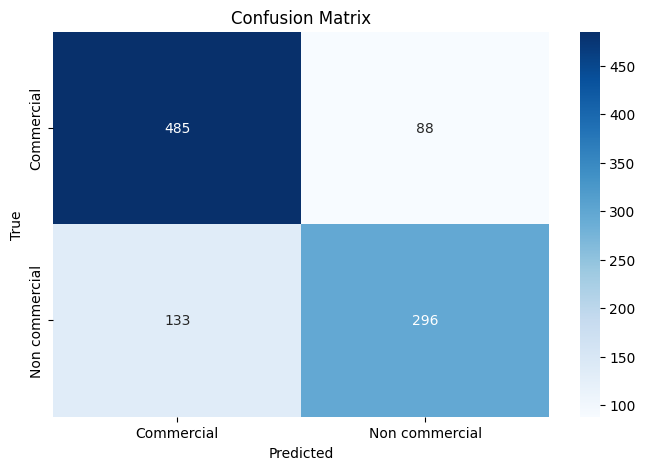

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
plot_confusion_matrix(all_labels, all_preds)